# Olist E-Commerce: Exploratory Data Analysis

This notebook analyzes the Olist dataset to establish the baseline facts about seller geography, dispatch times, review scores, and on-time delivery rates.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Use consistent styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook")

# Load the master processed table
master = pd.read_parquet('../data/processed/master.parquet')
print(f"Master table loaded: {master.shape[0]:,} rows x {master.shape[1]} columns")

Master table loaded: 112,650 rows x 30 columns


## Finding 1: Seller Geographic Concentration

Where are the sellers located? A high concentration in a single state could create structural supply chain risks.

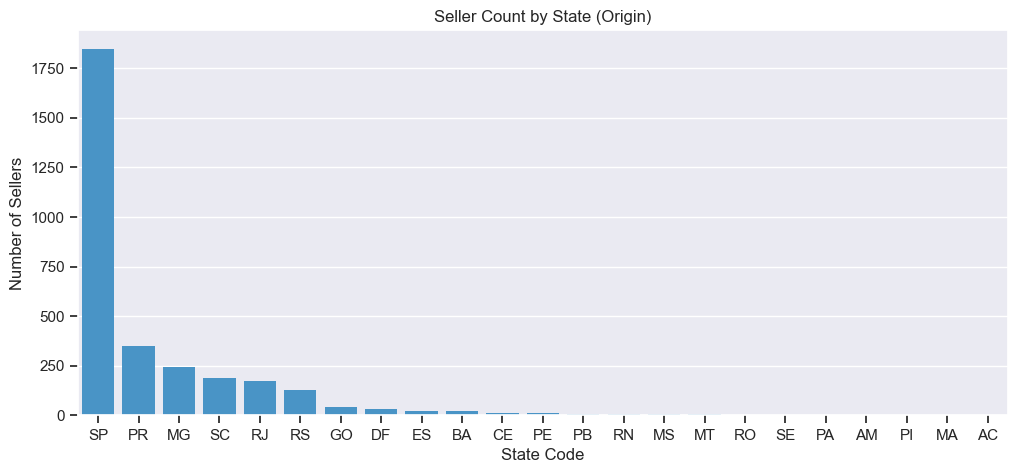

Finding: 59.7% of sellers are based in São Paulo (SP). This is real, not synthetic data.
This creates a geographic concentration risk — delayed shipments from this hub disproportionately affect national delivery performance.


In [2]:
# Get unique sellers and their states
sellers = master.drop_duplicates(subset=['seller_id'])
state_counts = sellers['seller_state'].value_counts()

plt.figure(figsize=(12, 5))
sns.barplot(x=state_counts.index, y=state_counts.values, color='#3498db')
plt.title('Seller Count by State (Origin)')
plt.ylabel('Number of Sellers')
plt.xlabel('State Code')
plt.show()

sp_pct = state_counts.loc['SP'] / state_counts.sum() * 100
print(f"Finding: {sp_pct:.1f}% of sellers are based in São Paulo (SP). This is real, not synthetic data.")
print("This creates a geographic concentration risk — delayed shipments from this hub disproportionately affect national delivery performance.")

## Finding 2: Dispatch Time Distribution

How long does it take for a seller to hand over the product to the logistics carrier?

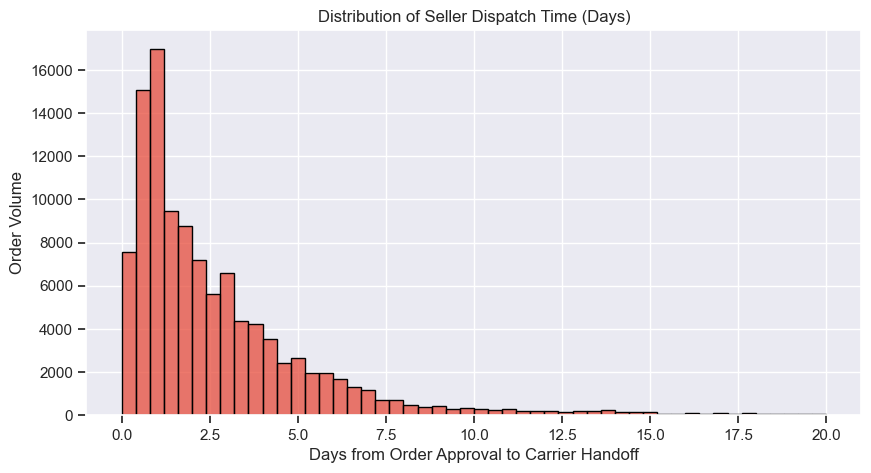

Median dispatch time: 1.9 days
95th percentile: 8.4 days
Finding: While most orders are dispatched in ~2 days, the long right tail indicates significant variation in seller reliability.


In [3]:
dispatch_data = master.loc[master['dispatch_days'] > 0, 'dispatch_days']

plt.figure(figsize=(10, 5))
sns.histplot(dispatch_data, bins=50, binrange=(0, 20), color='#e74c3c')
plt.title('Distribution of Seller Dispatch Time (Days)')
plt.xlabel('Days from Order Approval to Carrier Handoff')
plt.ylabel('Order Volume')
plt.show()

median_dispatch = dispatch_data.median()
p95_dispatch = dispatch_data.quantile(0.95)
print(f"Median dispatch time: {median_dispatch:.1f} days")
print(f"95th percentile: {p95_dispatch:.1f} days")
print(f"Finding: While most orders are dispatched in ~2 days, the long right tail indicates significant variation in seller reliability.")

## Finding 3: Review Score Distribution

Customer satisfaction is heavily right-skewed. This means a 1- or 2-star review is not just noise; it is a strong signal of failure.

C:\Users\Rohan\AppData\Local\Temp\ipykernel_7660\3333319577.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=master.drop_duplicates('order_id'), x='review_score', palette='viridis')


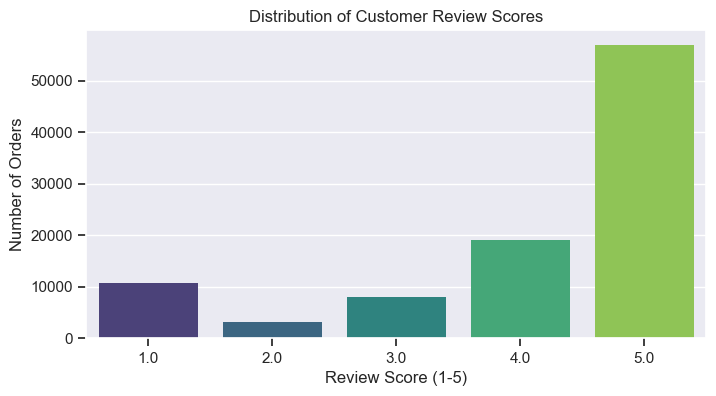

Finding: 1- and 2-star reviews make up only 14.2% of total reviews.
This skew makes low scores an excellent leading indicator of operational failure for our predictive model.


In [4]:
plt.figure(figsize=(8, 4))
sns.countplot(data=master.drop_duplicates('order_id'), x='review_score', palette='viridis')
plt.title('Distribution of Customer Review Scores')
plt.xlabel('Review Score (1-5)')
plt.ylabel('Number of Orders')
plt.show()

low_scores = master.drop_duplicates('order_id')['review_score'].value_counts(normalize=True).sort_index()
print(f"Finding: 1- and 2-star reviews make up only {(low_scores.get(1.0, 0) + low_scores.get(2.0, 0))*100:.1f}% of total reviews.")
print("This skew makes low scores an excellent leading indicator of operational failure for our predictive model.")

## Finding 4: On-Time Delivery Rate Over Time

Does the platform's reliability change over time? We look at the monthly OTD rate.

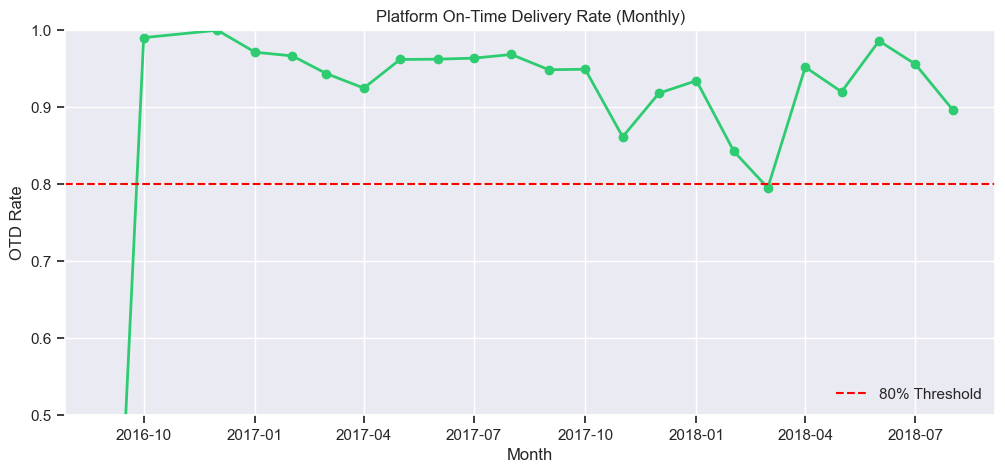

Finding: The OTD rate drops significantly in late 2017 and early 2018 (likely Black Friday and Holiday peaks).
This temporal variation confirms we must use a strict temporal split for our machine learning model.


In [5]:
# Calculate monthly OTD rate
monthly_otd = master[master['order_status'] == 'delivered'].groupby('purchase_month').agg(
    total_orders=('order_id', 'size'),
    on_time_orders=('on_time', 'sum')
)
monthly_otd['otd_rate'] = monthly_otd['on_time_orders'] / monthly_otd['total_orders']

# Convert period index to timestamp for plotting
monthly_otd.index = monthly_otd.index.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(monthly_otd.index, monthly_otd['otd_rate'], marker='o', color='#2ecc71', linewidth=2)
plt.axhline(0.8, color='red', linestyle='--', label='80% Threshold')
plt.title('Platform On-Time Delivery Rate (Monthly)')
plt.ylabel('OTD Rate')
plt.xlabel('Month')
plt.ylim(0.5, 1.0)
plt.legend()
plt.show()

print("Finding: The OTD rate drops significantly in late 2017 and early 2018 (likely Black Friday and Holiday peaks).")
print("This temporal variation confirms we must use a strict temporal split for our machine learning model.")

## Finding 5: Freight Value vs Delivery Time

Does paying more for freight mean faster delivery?

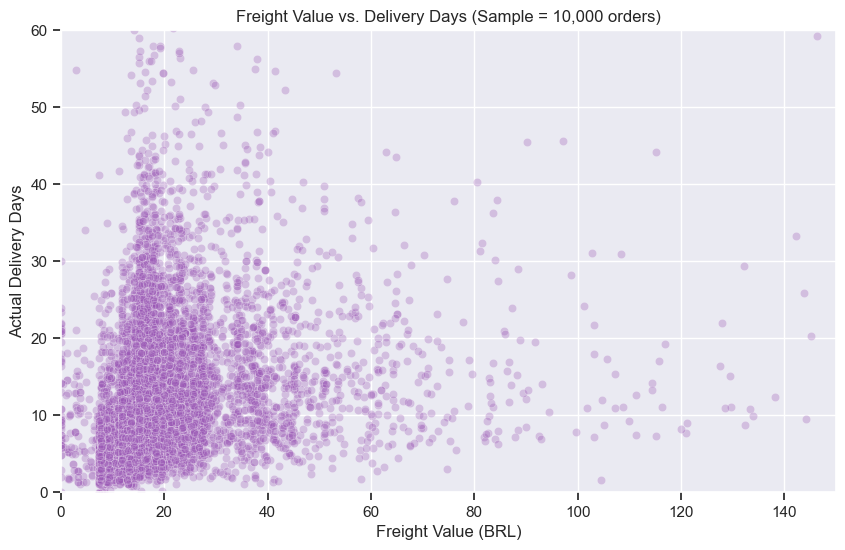

Finding: Higher freight values are driven by longer distances, which also naturally take longer to deliver.
There is no 'premium fast shipping' tier visible that breaks this correlation.


In [6]:
sample_df = master.sample(10000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x='freight_value', y='delivery_days', alpha=0.3, color='#9b59b6')
plt.title('Freight Value vs. Delivery Days (Sample = 10,000 orders)')
plt.xlabel('Freight Value (BRL)')
plt.ylabel('Actual Delivery Days')
plt.xlim(0, 150)
plt.ylim(0, 60)
plt.show()

print("Finding: Higher freight values are driven by longer distances, which also naturally take longer to deliver.")
print("There is no 'premium fast shipping' tier visible that breaks this correlation.")

## Finding 6: Churn Rate Baseline

Using our operational definition of seller churn, what is our target class balance?

In [7]:
train = pd.read_parquet('../data/processed/train_dataset.parquet')
test = pd.read_parquet('../data/processed/test_dataset.parquet')

train_churn = train['churned'].mean() * 100
test_churn = test['churned'].mean() * 100

print(f"Training Set Churn Rate (2017): {train_churn:.1f}%")
print(f"Test Set Churn Rate (2018): {test_churn:.1f}%")
print("\nFinding: A ~14% baseline churn rate is a highly realistic distribution for an early-warning system.")
print("This is imbalanced enough to require scale_pos_weight in XGBoost, but dense enough to learn a strong signal.")

Training Set Churn Rate (2017): 13.3%
Test Set Churn Rate (2018): 14.9%

Finding: A ~14% baseline churn rate is a highly realistic distribution for an early-warning system.
This is imbalanced enough to require scale_pos_weight in XGBoost, but dense enough to learn a strong signal.
